# Insight 5: resultado del pedido y feedback

La asociacion entre resultado del pedido y feedback fue alta en la exploracion (V de Cramer cercano a 0.585). Este analisis contrasta ambas variables y detalla la proporcion de feedback para cada resultado. Como son medidas relacionadas con la experiencia del servicio, parte de la asociacion puede ser esperable; no equivale a una relacion causal.

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

ruta_dataset = Path('..') / 'data' / 'online food delivery dataset.csv'
df = pd.read_csv(ruta_dataset)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
df = df.apply(
    lambda columna: columna.str.strip()
    if pd.api.types.is_string_dtype(columna.dtype)
    else columna
)

tabla = pd.crosstab(df['Output'], df['Feedback'])
porcentajes = pd.crosstab(df['Output'], df['Feedback'], normalize='index').mul(100)
display(tabla)
display(porcentajes.round(1))

Feedback,Negative,Positive
Output,,
No,53,34
Yes,18,283


Feedback,Negative,Positive
Output,,
No,60.9,39.1
Yes,6.0,94.0


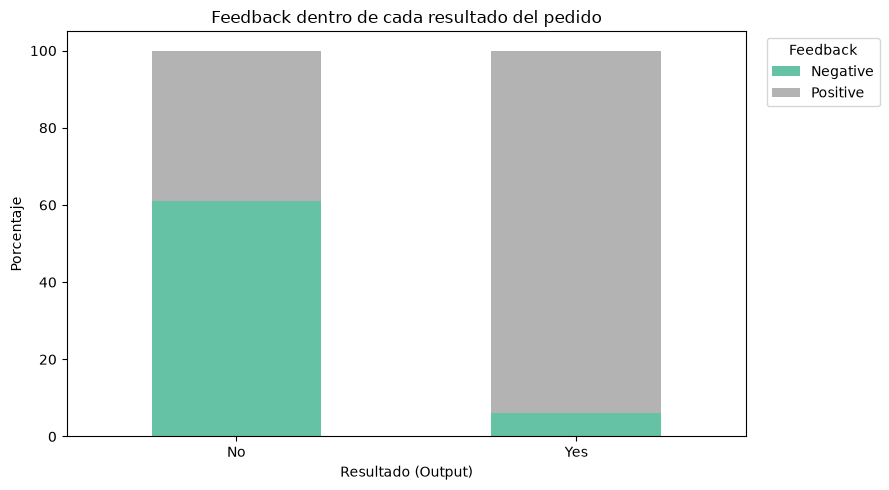

In [10]:
ax = porcentajes.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='Set2')
ax.set_title('Feedback dentro de cada resultado del pedido')
ax.set_xlabel('Resultado (Output)')
ax.set_ylabel('Porcentaje')
ax.legend(title='Feedback', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
chi2, p_valor, grados_libertad, esperadas = chi2_contingency(tabla)
n = tabla.to_numpy().sum()
filas, columnas = tabla.shape
phi2 = chi2 / n
phi2_corregido = max(0, phi2 - ((columnas - 1) * (filas - 1)) / (n - 1))
filas_corregidas = filas - ((filas - 1) ** 2) / (n - 1)
columnas_corregidas = columnas - ((columnas - 1) ** 2) / (n - 1)
v_cramer = (phi2_corregido / max(1, min(columnas_corregidas - 1, filas_corregidas - 1))) ** 0.5
print(f'Chi-cuadrado: {chi2:.3f} | gl: {grados_libertad} | p-valor: {p_valor:.6g}')
print(f"V de Cramer (corregida): {v_cramer:.3f}")
print('Asociacion estadisticamente significativa (alpha=0.05).' if p_valor < 0.05 else 'No se detecta asociacion estadisticamente significativa (alpha=0.05).')

Chi-cuadrado: 132.610 | gl: 1 | p-valor: 1.10029e-30
V de Cramer (corregida): 0.582
Asociacion estadisticamente significativa (alpha=0.05).


Output: categórica nominal dicotómica; dtype almacenado=str; categorías=['No', 'Yes']
Feedback: categórica nominal dicotómica; dtype almacenado=str; categorías=['Negative', 'Positive']


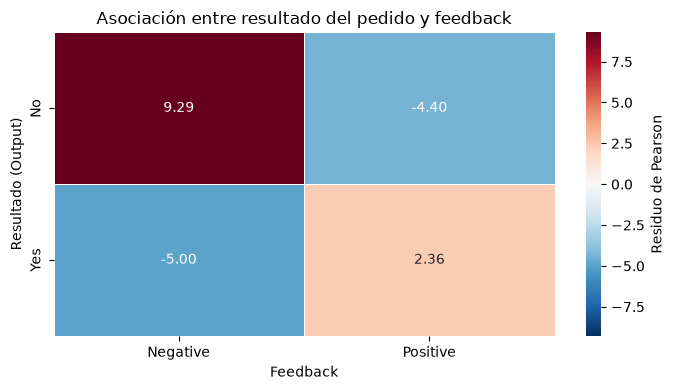

V de Cramer corregida (asociación global): 0.582
Residuo positivo: combinación más frecuente de lo esperado bajo independencia.


In [12]:
import numpy as np
import seaborn as sns

variables = ["Output", "Feedback"]
for variable in variables:
    categorias = sorted(df[variable].dropna().unique().tolist())
    print(
        f"{variable}: categórica nominal dicotómica; "
        f"dtype almacenado={df[variable].dtype}; categorías={categorias}"
    )

# Los residuos positivos indican más casos de los esperados bajo independencia.
tabla_asociacion = pd.crosstab(df["Output"], df["Feedback"])
_, _, _, frecuencias_esperadas = chi2_contingency(
    tabla_asociacion,
    correction=False,
)
residuos_pearson = (tabla_asociacion - frecuencias_esperadas) / np.sqrt(
    frecuencias_esperadas
)
limite_color = max(abs(residuos_pearson.to_numpy()).max(), 1)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    residuos_pearson,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-limite_color,
    vmax=limite_color,
    linewidths=0.5,
    cbar_kws={"label": "Residuo de Pearson"},
    ax=ax,
)
ax.set_title("Asociación entre resultado del pedido y feedback")
ax.set_xlabel("Feedback")
ax.set_ylabel("Resultado (Output)")
plt.tight_layout()
plt.show()

print(f"V de Cramer corregida (asociación global): {v_cramer:.3f}")
print("Residuo positivo: combinación más frecuente de lo esperado bajo independencia.")